In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

# Load catalog
cat = Table.read('/home/happy/fermi-lat-dm-project/data/raw/4fgl_dr4.fit', hdu=1)

print(f"Catalog loaded: {len(cat)} sources")
print(f"Number of columns: {len(cat.colnames)}")

Catalog loaded: 7195 sources
Number of columns: 79


In [8]:
# Cell 2b: Find the exact spectral column names
spectral_cols = [c for c in cat.colnames if any(x in c.lower() 
                for x in ['spec', 'index', 'beta', 'vari', 'class', 'pivot'])]
print("Spectral/classification columns available:")
for c in spectral_cols:
    print(f"  {c}")

Spectral/classification columns available:
  Pivot_Energy
  SpectrumType
  PL_Index
  Unc_PL_Index
  LP_Index
  Unc_LP_Index
  LP_beta
  Unc_LP_beta
  PLEC_IndexS
  Unc_PLEC_IndexS
  PLEC_Exp_Index
  Unc_PLEC_Exp_Index
  Variability_Index
  Frac_Variability
  Unc_Frac_Variability
  CLASS1
  CLASS2


In [9]:
# Cell 2 (fixed): Key columns with correct names
key_columns = [
    'Source_Name',
    'RAJ2000',
    'DEJ2000',
    'GLON',
    'GLAT',
    'Signif_Avg',
    'Energy_Flux100',
    'PL_Index',          # Power law spectral index
    'LP_beta',           # Spectral curvature
    'Variability_Index', # Time variability
    'CLASS1',            # Source class — your ML target label
]

print("=== KEY COLUMNS FOR ML ANALYSIS ===\n")
for col in key_columns:
    val = cat[col][0]
    print(f"  {col:<25} example value: {val}")

=== KEY COLUMNS FOR ML ANALYSIS ===

  Source_Name               example value: 4FGL J0000.3-7355 
  RAJ2000                   example value: 0.09830000251531601
  DEJ2000                   example value: -73.9219970703125
  GLON                      example value: 307.708984375
  GLAT                      example value: -42.72953796386719
  Signif_Avg                example value: 8.492646217346191
  Energy_Flux100            example value: 1.7352087648692116e-12
  PL_Index                  example value: 2.2473957538604736
  LP_beta                   example value: 0.10999862849712372
  Variability_Index         example value: 12.834996223449707
  CLASS1                    example value: --


In [10]:
# Cell 3: Build a clean DataFrame for ML analysis
import warnings
warnings.filterwarnings('ignore')

# Extract key features
df = pd.DataFrame({
    'name':       [str(s).strip() for s in cat['Source_Name']],
    'ra':         np.array(cat['RAJ2000'], dtype=float),
    'dec':        np.array(cat['DEJ2000'], dtype=float),
    'glon':       np.array(cat['GLON'], dtype=float),
    'glat':       np.array(cat['GLAT'], dtype=float),
    'significance': np.array(cat['Signif_Avg'], dtype=float),
    'energy_flux':  np.array(cat['Energy_Flux100'], dtype=float),
    'pl_index':     np.array(cat['PL_Index'], dtype=float),
    'lp_beta':      np.array(cat['LP_beta'], dtype=float),
    'variability':  np.array(cat['Variability_Index'], dtype=float),
    'class1':     [str(c).strip() for c in cat['CLASS1']],
})

# Create clean source type labels
def simplify_class(c):
    c = c.strip().lower()
    if c in ['--', '', 'unk']:  return 'unassociated'
    if c in ['bll', 'fsrq', 'bcu', 'rdg', 'agn']:  return 'AGN'
    if c in ['psr', 'msp']:  return 'pulsar'
    if c in ['snr', 'spp']:  return 'SNR/PWN'
    return 'other'

df['source_type'] = df['class1'].apply(simplify_class)

# Summary
print("=== DATASET SUMMARY ===")
print(df['source_type'].value_counts())
print(f"\nTotal sources: {len(df)}")
print(f"\nFeature matrix shape: {df.shape}")
print(f"\nAny NaN values: {df.isnull().sum().sum()}")


=== DATASET SUMMARY ===
source_type
AGN             3994
unassociated    2563
pulsar           320
SNR/PWN          176
other            142
Name: count, dtype: int64

Total sources: 7195

Feature matrix shape: (7195, 12)

Any NaN values: 5


NameError: name 'p' is not defined

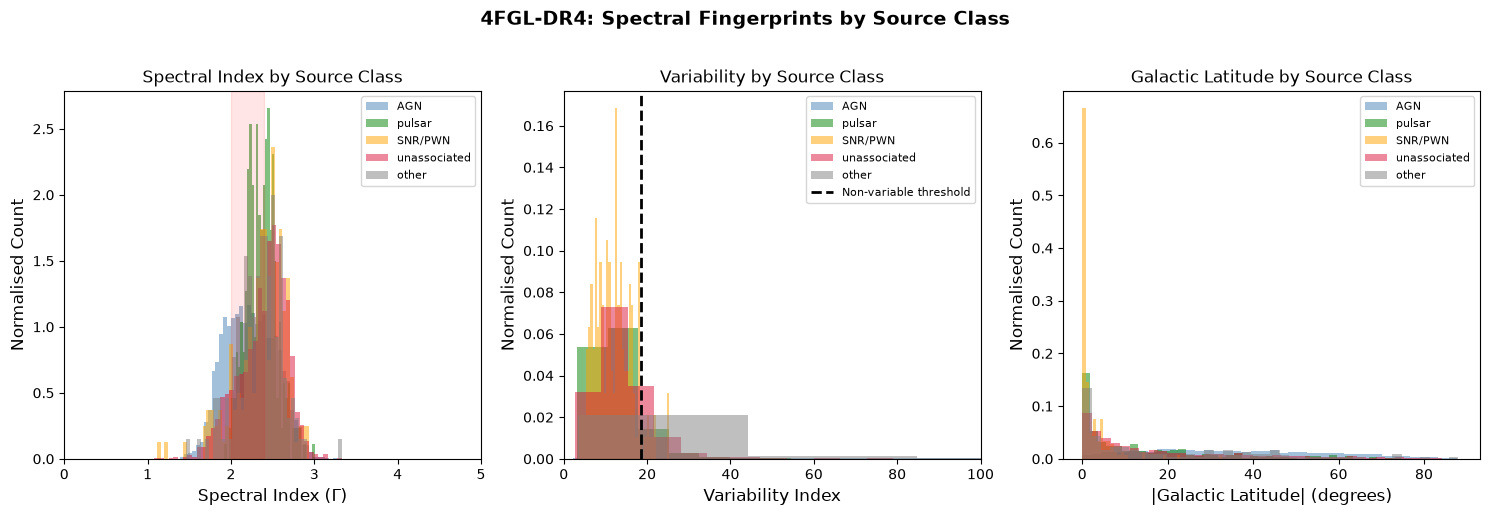

In [11]:
# Cell 4: Spectral fingerprints of each source class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {
    'AGN': 'steelblue',
    'pulsar': 'green',
    'SNR/PWN': 'orange',
    'unassociated': 'crimson',
    'other': 'grey'
}

# Drop NaN rows for plotting
df_clean = df.dropna()

# ── Plot 1: Spectral Index distribution ───────────────────
ax = axes[0]
for stype, color in colors.items():
    subset = df_clean[df_clean['source_type'] == stype]
    ax.hist(subset['pl_index'], bins=40, alpha=0.5,
            color=color, label=stype, density=True)
ax.set_xlabel('Spectral Index (Γ)', fontsize=12)
ax.set_ylabel('Normalised Count', fontsize=12)
ax.set_title('Spectral Index by Source Class', fontsize=12)
ax.set_xlim(0, 5)
ax.legend(fontsize=8)
ax.axvspan(2.0, 2.4, alpha=0.1, color='red', label='DM expected range')

# ── Plot 2: Variability Index ──────────────────────────────
ax = axes[1]
for stype, color in colors.items():
    subset = df_clean[df_clean['source_type'] == stype]
    ax.hist(subset['variability'], bins=40, alpha=0.5,
            color=color, label=stype, density=True)
ax.axvline(x=18.48, color='black', linestyle='--', linewidth=2,
           label='Non-variable threshold')
ax.set_xlabel('Variability Index', fontsize=12)
ax.set_ylabel('Normalised Count', fontsize=12)
ax.set_title('Variability by Source Class', fontsize=12)
ax.set_xlim(0, 100)
ax.legend(fontsize=8)

# ── Plot 3: Galactic latitude ──────────────────────────────
ax = axes[2]
for stype, color in colors.items():
    subset = df_clean[df_clean['source_type'] == stype]
    ax.hist(np.abs(subset['glat']), bins=40, alpha=0.5,
            color=color, label=stype, density=True)
ax.set_xlabel('|Galactic Latitude| (degrees)', fontsize=12)
ax.set_ylabel('Normalised Count', fontsize=12)
ax.set_title('Galactic Latitude by Source Class', fontsize=12)
ax.legend(fontsize=8)

plt.suptitle('4FGL-DR4: Spectral Fingerprints by Source Class',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/happy/fermi-lat-dm-project/results/figures/spectral_fingerprints.png',
            dpi=150, bbox_inches='tight')
p